# NeuralGCM: spatial generalization test grid

Reproduces `neuralgcm_encode_decode_error_grid.png`
-- an encoder/decoder reconstruction-error grid (input, reconstruction, error, and
difference from baseline) for a pretrained NeuralGCM model, evaluated under four
spatial transformations: baseline, rotated longitude, reversed latitude and
reversed longitude.

## Config

In [1]:
# Pretrained NeuralGCM checkpoint (public GCS bucket, no auth needed)
MODEL_NAME = 'v1_precip/stochastic_precip_2_8_deg.pkl'

# The figure below is written here.
import os
os.makedirs('figures', exist_ok=True)

# Regridded ERA5 input data -- see the "Get regridded ERA5 data" section below.
# Fetched from Zenodo by default; falls back to this local path if already present.
DATA_DIR = "../data/NeuralGCM/regridded_era5"

# Only used if you regenerate the regridded ERA5 data from scratch instead of
# downloading the cache (see the optional section below).
REGRID_CHUNKS_DIR = "../data/NeuralGCM/regridded_era5/chunks"
# Set True to reproduce combined_regridded_data_era5.nc from the raw public
# ERA5 zarr archive instead of using the cached/downloaded file (see the
# "[OPTIONAL] Regenerate regridded ERA5 from scratch" section below). This is
# memory- and time-heavy (full ARCO-ERA5 zarr pull + regrid) -- leave False
# unless you specifically need to regenerate the cache.
REGENERATE_FROM_SCRATCH = False


## Imports

In [2]:
import gcsfs
import jax
import numpy as np

import pickle
import xarray 
import matplotlib.pyplot as plt
import cmocean

from dinosaur import horizontal_interpolation
from dinosaur import spherical_harmonic
from dinosaur import xarray_utils
import neuralgcm

from argumentation_functions import flip

## Load pretrained model checkpoint

In [3]:
model_name = MODEL_NAME

gcs = gcsfs.GCSFileSystem(token='anon')
with gcs.open(f'gs://neuralgcm/models/{model_name}', 'rb') as f:
  ckpt = pickle.load(f)
model = neuralgcm.PressureLevelModel.from_checkpoint(ckpt)

## Get regridded ERA5 data

The optional pipeline below takes ERA5 from the public ARCO-ERA5 Zarr store and
regrids it to NeuralGCM's native resolution -- slow (116 chunks) and heavy on
network traffic. The combined result (`combined_regridded_data_era5.nc`, ~12.9 GB)
is on Zenodo and is downloaded instead by default.

In [4]:
import sys
sys.path.insert(0, "../common")
from zenodo_fetch import ensure_zenodo_files

# --- TEMPORARY: data is on Zenodo's sandbox while the paper is under review ---
# Sandbox records are periodically wiped and their DOIs (10.5072/...) are not
# real. When the record is published on the real Zenodo, delete these two lines
# and replace the record id(s) below with the real one(s).
import os
os.environ["ZENODO_BASE_URL"] = "https://sandbox.zenodo.org"
# -----------------------------------------------------------------------------

# Zenodo record holding the regridded ERA5 data.
ZENODO_RECORD_NEURALGCM = "586393"

ensure_zenodo_files(ZENODO_RECORD_NEURALGCM, {
    "combined_regridded_data_era5.nc": "0a9e15583d2e56bcf466c2ba68e34f6f",
}, DATA_DIR)

era5_regridded = xarray.open_dataset(f"{DATA_DIR}/combined_regridded_data_era5.nc", engine="netcdf4")

### [OPTIONAL] Regenerate regridded ERA5 from scratch

Controlled by `REGENERATE_FROM_SCRATCH` in the Config cell (default `False`) and
skipped by default -- the cell above already gets you `era5_regridded` from the
downloaded file. Enable it only if you want to rebuild
`combined_regridded_data_era5.nc` from raw public ERA5 data. This pulls the full
ARCO-ERA5 Zarr archive and regrids it, which is demanding on both memory and time.
Output locations come from `REGRID_CHUNKS_DIR` and `DATA_DIR` in the Config cell.

In [5]:
if REGENERATE_FROM_SCRATCH:
    era5_path = 'gs://gcp-public-data-arco-era5/ar/full_37-1h-0p25deg-chunk-1.zarr-v3'
    full_era5 = xarray.open_zarr(
        era5_path, chunks=None, storage_options=dict(token='anon')
    )

    demo_start_time = '2021-12-31'
    demo_end_time = '2023-01-11'
    data_inner_steps = 6  # process every 6th hour

    sliced_era5 = (
        full_era5
        [model.input_variables + model.forcing_variables]
        .pipe(
            xarray_utils.selective_temporal_shift,
            variables=model.forcing_variables,
            time_shift='24 hours',
        )
        .sel(time=slice(demo_start_time, demo_end_time, data_inner_steps))
        #.compute()
    )

In [6]:
if REGENERATE_FROM_SCRATCH:
    era5_grid = spherical_harmonic.Grid(
        latitude_nodes=full_era5.sizes['latitude'],
        longitude_nodes=full_era5.sizes['longitude'],
        latitude_spacing=xarray_utils.infer_latitude_spacing(full_era5.latitude),
        longitude_offset=xarray_utils.infer_longitude_offset(full_era5.longitude),
    )
    regridder = horizontal_interpolation.ConservativeRegridder(
        era5_grid, model.data_coords.horizontal, skipna=True
    )
    #eval_era5 = xarray_utils.regrid(sliced_era5, regridder)
    #eval_era5 = xarray_utils.fill_nan_with_nearest(eval_era5)

In [7]:
%%time
if REGENERATE_FROM_SCRATCH:
    for d in range(0,int(len(sliced_era5.time)/13)):
        current_data = sliced_era5.sel(time=sliced_era5.time[d*13:d*13+13])
        regridded_current = xarray_utils.regrid(current_data, regridder)
        regridded_current = xarray_utils.fill_nan_with_nearest(regridded_current)
        import os
        os.makedirs(REGRID_CHUNKS_DIR, exist_ok=True)
        regridded_current.to_netcdf(f"{REGRID_CHUNKS_DIR}/regridded_data_era5_{d}.nc")
        print(d)
    import time
    time.sleep(2)

CPU times: user 6 μs, sys: 1 μs, total: 7 μs
Wall time: 14.8 μs


In [8]:
if REGENERATE_FROM_SCRATCH:
    file_paths = []
    for num in np.arange(116):
        current_path = f"{REGRID_CHUNKS_DIR}/regridded_data_era5_{num}.nc"
        file_paths.append(current_path)

In [9]:
if REGENERATE_FROM_SCRATCH:
    era5_regridded = xarray.open_mfdataset(
        file_paths,
        concat_dim="time",
        combine="nested",
        parallel=True,
        chunks={"time": 100}  # Adjust chunk size based on available memory
    )

In [10]:
if REGENERATE_FROM_SCRATCH:
    era5_regridded = era5_regridded.sel(time = era5_regridded.time[3:]) # make First datapoint 2022-12-31 18:00

In [11]:
if REGENERATE_FROM_SCRATCH:
    era5_regridded.to_netcdf(f"{DATA_DIR}/combined_regridded_data_era5.nc")

## Analysis parameters

In [12]:
# The timestep the figure is made from: index 0, the first in the file.
# This was a list of twelve indices -- the last day of each month at 18:00,
# [0, 124, 236, 360, 480, 604, 724, 848, 972, 1092, 1216, 1336] -- but only the
# first was ever used, so it is the single index it always was in practice.
TIME_INDEX = 0


In [13]:
temp_vmin = 230
temp_vmax = 320
max_abs_error = 7

## Produce the figure

Writes `neuralgcm_encode_decode_error_grid.png`, at 150 dpi.


Processing Baseline


Processing Rotate Longitude


Processing Reversed Latitude


Processing Reversed Longitude


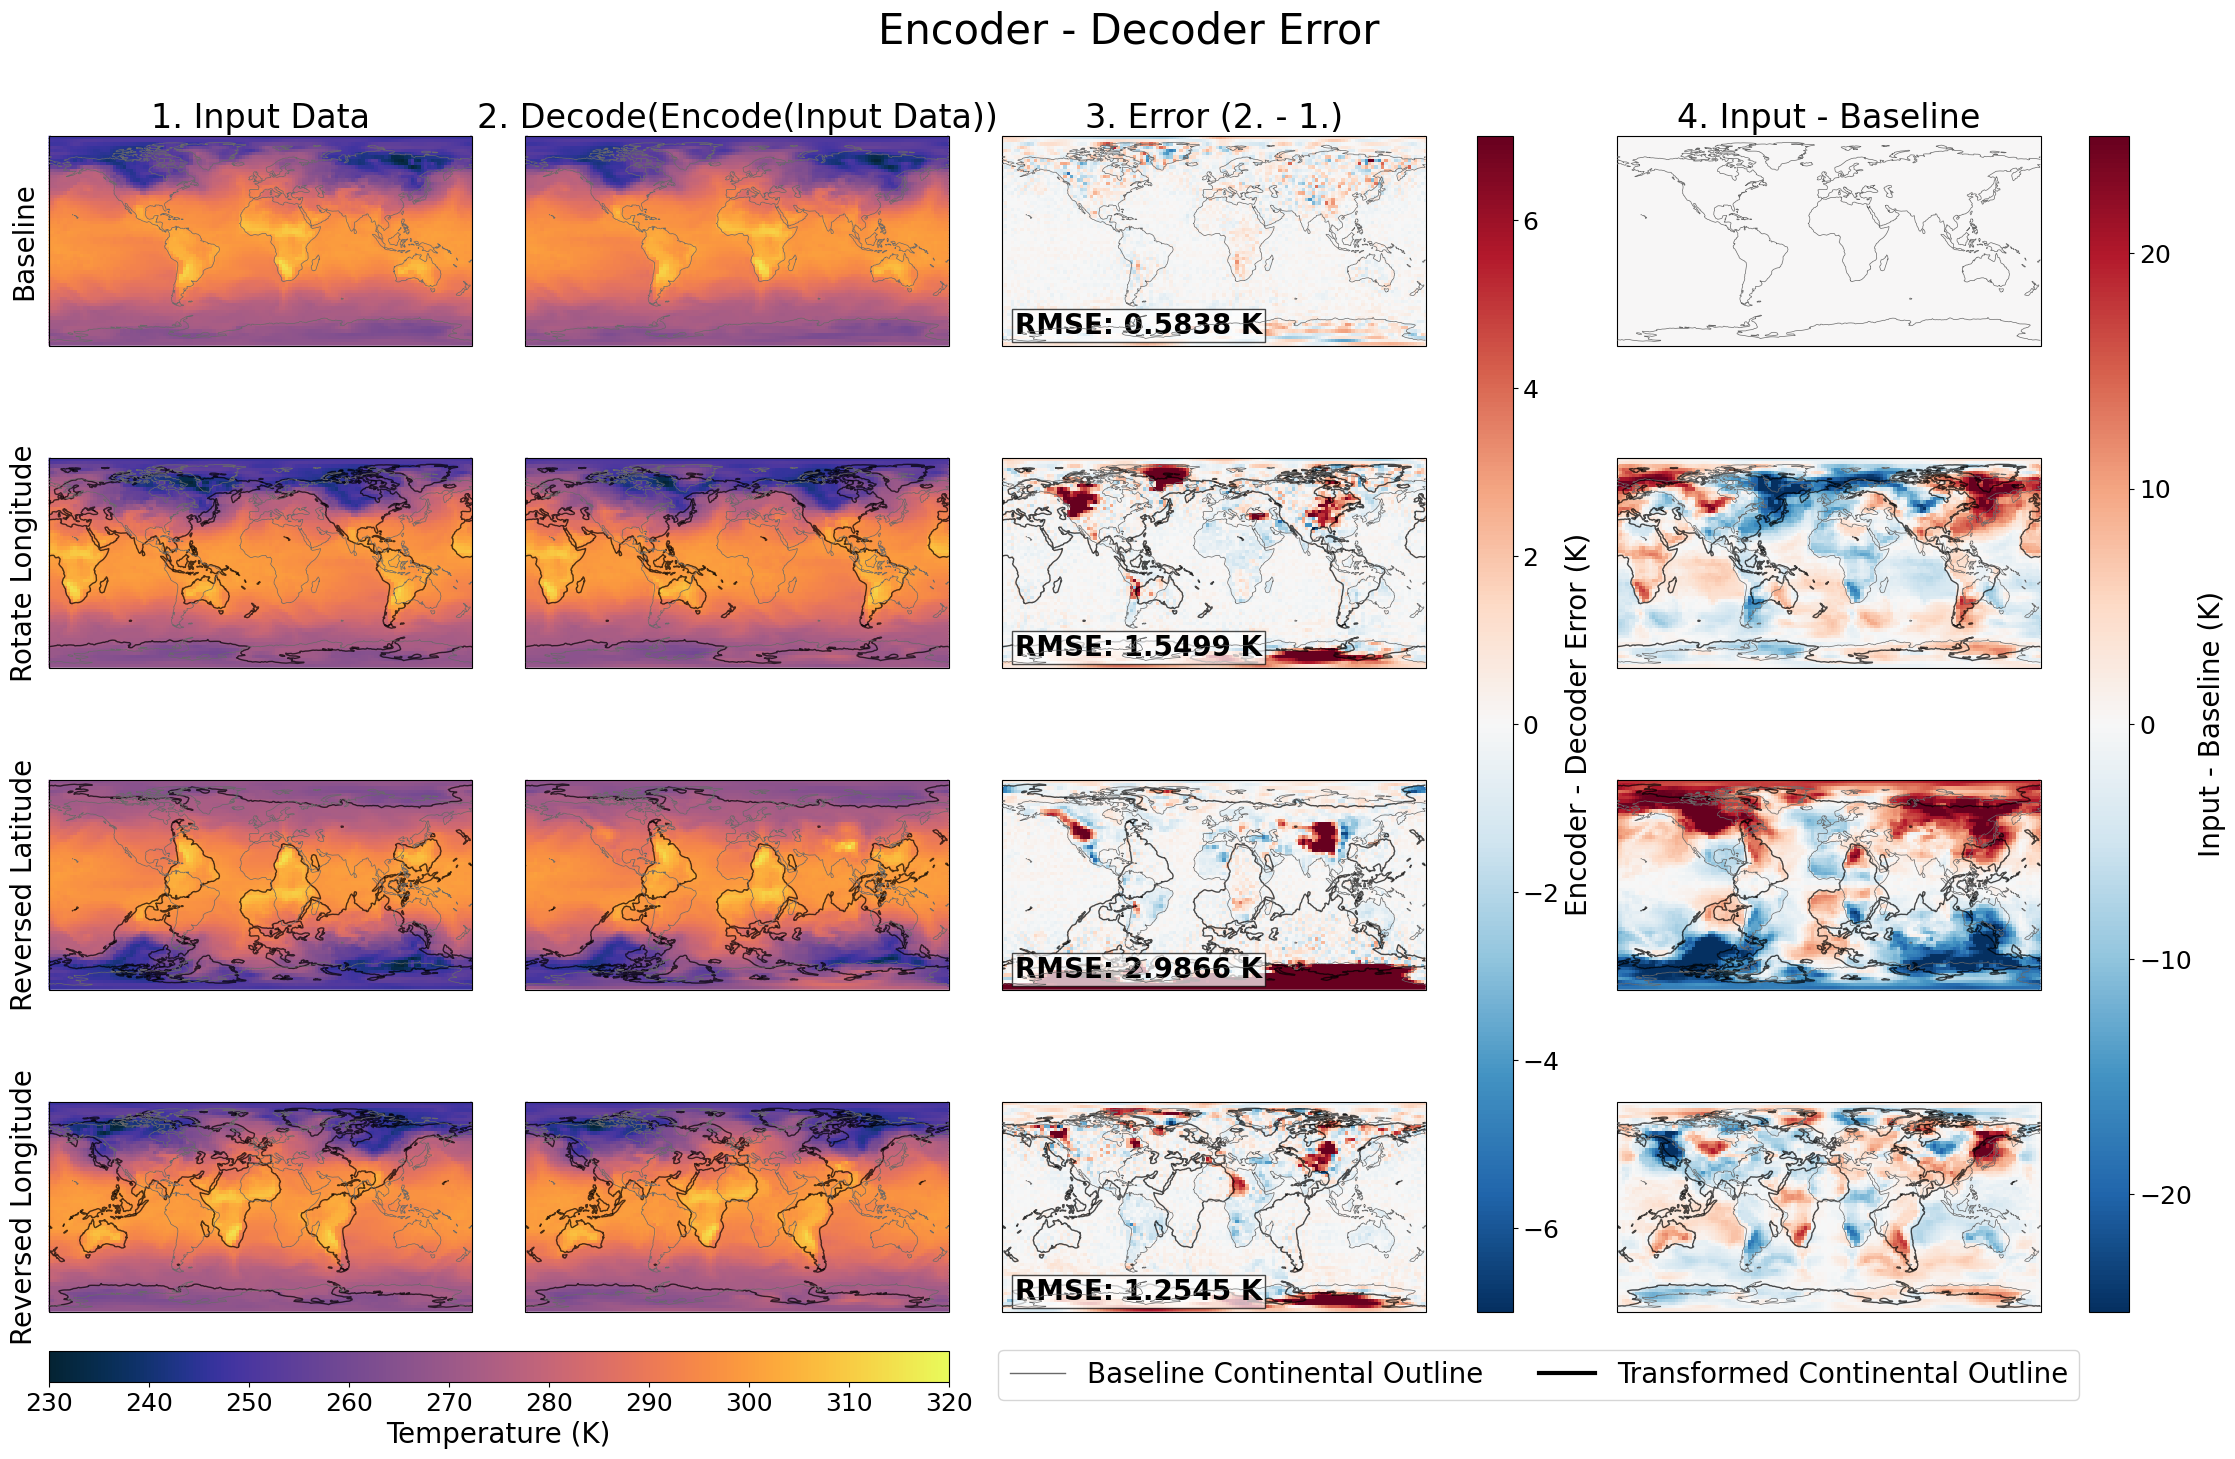

In [14]:
from matplotlib.lines import Line2D
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import shapely.affinity as saffin
import numpy as np

# ---------------- SETTINGS ----------------
baseline_diff_limit = 25  # <-- SET MANUALLY (adjust as needed)

# --- Setup for the plot grid ---
flip_types = ['', 'rotlon', 'revlat', 'revlon']
flip_titles = ['Baseline', 'Rotate Longitude', 'Reversed Latitude', 'Reversed Longitude']

# --- Compute baseline reference once ---
baseline_data = flip(era5_regridded.copy(), '')
baseline_input = baseline_data['temperature'][TIME_INDEX, 36, :, :].values.T

# Create 4x4 figure
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(24, 14))
gs = gridspec.GridSpec(
    4, 5,                      # 5 columns now
        width_ratios=[1, 1, 1, 0.2, 1],  # narrow gap before col 4
    wspace=0.15,
    hspace=0.0
)

axes = np.empty((4, 4), dtype=object)

for row in range(4):
    axes[row, 0] = fig.add_subplot(gs[row, 0], projection=ccrs.PlateCarree())
    axes[row, 1] = fig.add_subplot(gs[row, 1], projection=ccrs.PlateCarree())
    axes[row, 2] = fig.add_subplot(gs[row, 2], projection=ccrs.PlateCarree())
    axes[row, 3] = fig.add_subplot(gs[row, 4], projection=ccrs.PlateCarree())

fig.suptitle('Encoder - Decoder Error', fontsize=30, y=0.98)

# ---------------- MAIN LOOP ----------------
for i, (flip_type, title) in enumerate(zip(flip_types, flip_titles)):

    print(f"Processing {title}")

    flipped_data = flip(era5_regridded.copy(), flip_type)
    eval_era5 = flipped_data.sel(
        time=slice(flipped_data.time[TIME_INDEX],
                   flipped_data.time[TIME_INDEX + 4])
    )

    # Encode / Decode
    inputs = model.inputs_from_xarray(eval_era5.isel(time=0))
    input_forcings = model.forcings_from_xarray(eval_era5.isel(time=0))
    rng_key = jax.random.key(42)
    encoded = model.encode(inputs, input_forcings, rng_key)
    decoded = model.decode(encoded, input_forcings)

    # First index is the timestep, second is the level. The timestep must be the
    # same one the encode/decode below is evaluated at, or the error columns
    # would compare two different times.
    input_map_data = flipped_data['temperature'][TIME_INDEX, 36, :, :].values.T
    reconstructed = decoded['temperature'][36, :, :].T

    # -------- Column 1: Input --------
    ax1 = axes[i, 0]
    ax1.set_aspect(1)
    im1 = ax1.pcolormesh(
        flipped_data.longitude,
        flipped_data.latitude,
        input_map_data,
        shading='auto',
        cmap=cmocean.cm.thermal,
        vmin=temp_vmin,
        vmax=temp_vmax,
        transform=ccrs.PlateCarree()
    )
    ax1.text(-0.025, 0.5, title,
             transform=ax1.transAxes,
             ha='right', va='center',
             fontsize=20, rotation=90)

    # -------- Column 2: Reconstruction --------
    ax2 = axes[i, 1]
    ax2.set_aspect(1)
    ax2.pcolormesh(
        eval_era5.longitude,
        eval_era5.latitude,
        reconstructed,
        shading='auto',
        cmap=cmocean.cm.thermal,
        vmin=temp_vmin,
        vmax=temp_vmax,
        transform=ccrs.PlateCarree()
    )

    # -------- Column 3: Reconstruction Error --------
    ax3 = axes[i, 2]
    ax3.set_aspect(1)

    reconstruction_error = reconstructed - input_map_data

    im3 = ax3.pcolormesh(
        eval_era5.longitude,
        eval_era5.latitude,
        reconstruction_error,
        shading='auto',
        cmap='RdBu_r',
        vmin=-max_abs_error,
        vmax=max_abs_error,
        transform=ccrs.PlateCarree()
    )

    # RMSE
    weights = np.cos(np.deg2rad(eval_era5.latitude)).values
    squared_error = (input_map_data - reconstructed) ** 2
    weighted_se = squared_error * weights.reshape(-1, 1)
    weighted_mse = weighted_se.sum() / (weights * weighted_se.shape[1]).sum()
    RMSE = np.sqrt(weighted_mse)

    ax3.text(
        0.03, 0.03,
        f'RMSE: {RMSE:.4f} K',
        transform=ax3.transAxes,
        ha='left', va='bottom',
        fontsize=20,
        fontweight='bold',
        bbox={'facecolor': 'white', 'alpha': 0.7, 'pad': 2}
    )

    # -------- Column 4: Input - Baseline --------
    ax4 = axes[i, 3]
    ax4.set_aspect(1)

    diff_from_baseline = input_map_data - baseline_input

    im4 = ax4.pcolormesh(
        flipped_data.longitude,
        flipped_data.latitude,
        diff_from_baseline,
        shading='auto',
        cmap='RdBu_r',
        vmin=-baseline_diff_limit,
        vmax=baseline_diff_limit,
        transform=ccrs.PlateCarree()
    )

    # -------- Coastlines --------
    for ax in [ax1, ax2, ax3, ax4]:

        ax.add_feature(
            cfeature.COASTLINE,
            linewidth=0.5,
            zorder=10,
            edgecolor='dimgray'
        )

        if flip_type == 'rotlon':
            ax.add_feature(
                cfeature.COASTLINE,
                linewidth=1,
                edgecolor='black',
                alpha=0.7,
                transform=ccrs.PlateCarree(central_longitude=180)
            )

        elif flip_type == 'revlat':
            geoms = [saffin.scale(geom, yfact=-1, origin=(0, 0))
                     for geom in cfeature.COASTLINE.geometries()]
            ax.add_geometries(
                geoms,
                crs=ccrs.PlateCarree(),
                edgecolor='black',
                facecolor='none',
                linewidth=1,
                alpha=0.7
            )

        elif flip_type == 'revlon':
            geoms = [saffin.scale(geom, xfact=-1, origin=(0, 0))
                     for geom in cfeature.COASTLINE.geometries()]
            ax.add_geometries(
                geoms,
                crs=ccrs.PlateCarree(),
                edgecolor='black',
                facecolor='none',
                linewidth=1,
                alpha=0.7
            )

        ax.tick_params(left=False, labelleft=False,
                       bottom=False, labelbottom=False)

    # -------- Column Titles (Top Row Only) --------
    if i == 0:
        ax1.set_title('1. Input Data', fontsize=24)
        ax2.set_title('2. Decode(Encode(Input Data))', fontsize=24)
        ax3.set_title('3. Error (2. - 1.)', fontsize=24)
        ax4.set_title('4. Input - Baseline', fontsize=24)

# ---------------- COLORBARS ----------------

# Temperature (bottom horizontal)
cbar_ax_temp = fig.add_axes([0.05, 0, 0.375, 0.022]) #0.574
cbar_temp = fig.colorbar(im1, cax=cbar_ax_temp, orientation='horizontal')
cbar_temp.set_label('Temperature (K)', fontsize=20)
cbar_temp.ax.tick_params(labelsize=18)

cbar_ax_err = fig.add_axes([0.645, 0.05, 0.015, 0.84])
cbar_err = fig.colorbar(im3, cax=cbar_ax_err)
cbar_err.set_label('Encoder - Decoder Error (K)', fontsize=20)
cbar_err.ax.tick_params(labelsize=18)

# Column 4 colorbar (next to column 4)
cbar_ax_base = fig.add_axes([0.9, 0.05, 0.017, 0.84])
cbar_base = fig.colorbar(im4, cax=cbar_ax_base)
cbar_base.set_label('Input - Baseline (K)', fontsize=20)
cbar_base.ax.tick_params(labelsize=18)
# ---------------- LEGEND ----------------
legend_elements = [
    Line2D([0], [0], color='dimgray', lw=1,
           label='Baseline Continental Outline'),
    Line2D([0], [0], color='black', lw=3,
           label='Transformed Continental Outline')
]

fig.legend(
    handles=legend_elements,
    loc='center left',
    bbox_to_anchor=(0.44, 0.005),
    ncol=2,
    fontsize=20,
    frameon=True
)

plt.subplots_adjust(
    left=0.05,
    right=0.88,
    top=0.93,
    bottom=0.01,
    hspace=0.0,
    wspace=0.05
)

plt.savefig(
    "figures/neuralgcm_encode_decode_error_grid.png",
    dpi=150,
    bbox_inches='tight'
)

plt.show()